# Example Digital Analog computer

## ***The script with comments from copilot***

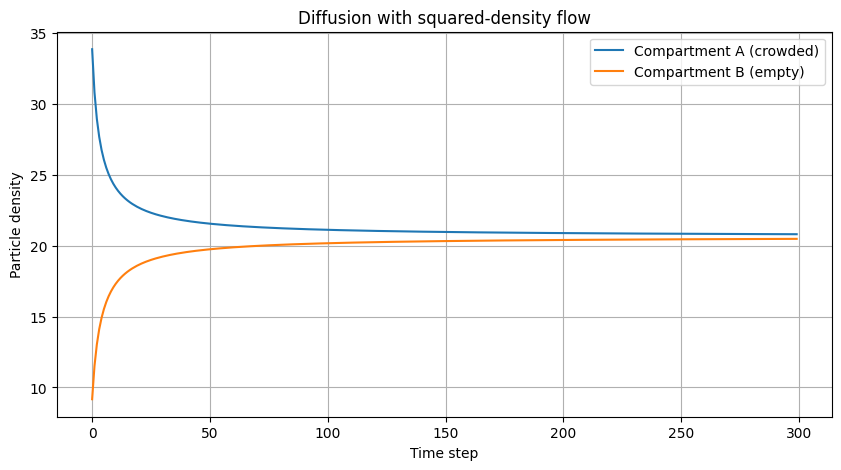

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. NODE — flow conservation (sum of flows = 0)
# ============================================================
# The node is a class of objects that has a name, a intial voltage of 0 and has multiple current pipes connected to it.
# I can have as many nodes with unique names as I need.
class Node:
    def __init__(self, name, initial_V=0):
        self.name = name
        self.V = initial_V      # particle density (voltage)
        self.flows = []         # list of functions returning flow

    def add_flow(self, flow_function):                   # This is a method that adds the present current
                                                        # to the current calculated in flow_function
        self.flows.append(flow_function)                # adds currnt to existint current

    def net_flow(self):                                  # this sums all the currents flowing into this note.
        return sum(f() for f in self.flows)


# ============================================================
# 2. RESISTOR — flow proportional to voltage
# ============================================================
# The Resistor is a class of objects that has a name,
class Resistor:
    def __init__(self, G, V_source):
        self.G = G              # conductance
        self.V_source = V_source

    def flow(self):
        return self.G * self.V_source()


# ============================================================
# 3. CAPACITOR — storage of particles
# ============================================================

class Capacitor:
    def __init__(self, C, node):
        self.C = C
        self.node = node

    def update(self, dt):
        I = self.node.net_flow()                 # I is the flow rate specified by the 
        self.node.V += (I / self.C) * dt 


# ============================================================
# 4. DIFFUSION — flow ∝ square of density difference
# ============================================================
# 
class Diffusion:
    def __init__(self, k, V1, V2):
        self.k = k                        # diffusion coef
        self.V1 = V1                      # voltage [number of People] AT 1 NODE
        self.V2 = V2                      # voltage [number of People] AT 2 NODE

    def flow_1_to_2(self):
        d = self.V1() - self.V2()        # The density differenct or gradient
        return self.k * d * abs(d)       # flow is coeficint time difference squred where sign is the direction

    def flow_2_to_1(self):
        return -self.flow_1_to_2()


# ============================================================
# DEMO SYSTEM — two compartments exchanging particles
# ============================================================

# Create nodes

#A = Node("A", initial_V=10)   # crowded compartment
#B = Node("B", initial_V=2)    # empty compartment
A = Node("A", initial_V=40)   # crowded compartment
B = Node("B", initial_V=5)    # empty compartment

# Create diffusion block
D = Diffusion(k=0.05, V1=lambda: A.V, V2=lambda: B.V)

# Connect flows to nodes
A.add_flow(lambda: -D.flow_1_to_2())   # A loses particles
B.add_flow(lambda:  D.flow_1_to_2())   # B gains particles

# Add capacitors (storage)
CapA = Capacitor(C=1.0, node=A)
CapB = Capacitor(C=1.0, node=B)

# ============================================================
# SIMULATION LOOP
# ============================================================

dt = 0.1                           # step size 
steps = 300                        # number of steps

A_history = []                      # list starts with A_history[0] and calcs the charge[A people] in room at each step
B_history = []

for _ in range(steps):
    CapA.update(dt)                 # Updates the charge by [I*dt] or capitor voltage = [Q/C] in the capacitorA for each calc
    CapB.update(dt)
    A_history.append(A.V)           # Append adds another value to a list
    B_history.append(B.V)

# ============================================================
# PLOT RESULTS
# ============================================================

plt.figure(figsize=(10,5))
plt.plot(A_history, label="Compartment A (crowded)")
plt.plot(B_history, label="Compartment B (empty)")
plt.xlabel("Time step")
plt.ylabel("Particle density")
plt.title("Diffusion with squared-density flow")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# verify 
A_history[0]

9.68

In [30]:
# verify 
CapA.update(dt)                       # updates value but does shaw the value

In [29]:
# verify d = self.V1()

In [6]:
# verify 
A_history[0]

9.68

# Show that methods in the op amp is a transdconduce and I out vs V in for a specified connection

In [69]:
dt = 0.1
#steps = 300

A_history = []
B_history = []

#for _ in range(steps):
CapA.update(dt)
CapB.update(dt)
A_history.append(A.V)
B_history.append(B.V)


In [70]:
A_history[0]

9.68

# Simple op amp.

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. NODE — flow conservation (sum of flows = 0)
# ============================================================

class Node:
    def __init__(self, name, initial_V=0):
        self.name = name
        self.V = initial_V      # particle density (voltage)
        self.flows = []         # list of functions returning flow

    def add_flow(self, flow_function):
        self.flows.append(flow_function)

    def net_flow(self):
        return sum(f() for f in self.flows)


# ============================================================
# 2. RESISTOR — flow proportional to voltage difference
# ============================================================

class Resistor:
    def __init__(self, R, V1, V2):
        self.R = R              # resistance
        self.V1 = V1            # function returning voltage at one end
        self.V2 = V2            # function returning voltage at other end

    def flow(self):
        return (self.V1() - self.V2()) / self.R


# ============================================================
# 3. CAPACITOR — storage of particles
# ============================================================

class Capacitor:
    def __init__(self, C, node):
        self.C = C
        self.node = node

    def update(self, dt):
        I = self.node.net_flow()
        self.node.V += (I / self.C) * dt


# ============================================================
# 4. DIFFUSION — flow √ square of density difference
# ============================================================

class Diffusion:
    def __init__(self, k, V1, V2):
        self.k = k
        self.V1 = V1
        self.V2 = V2

    def flow_1_to_2(self):
        d = self.V1() - self.V2()
        return self.k * d * abs(d)

    def flow_2_to_1(self):
        return -self.flow_1_to_2()


# ============================================================
# DEMO SYSTEM — two compartments exchanging particles
# ============================================================

# Create nodes
A = Node("A", initial_V=10)   # crowded compartment
B = Node("B", initial_V=2)    # empty compartment

# Create diffusion block
D = Diffusion(k=0.05, V1=lambda: A.V, V2=lambda: B.V)

# Connect flows to nodes
A.add_flow(lambda: -D.flow_1_to_2())   # A loses particles
B.add_flow(lambda:  D.flow_1_to_2())   # B gains particles

# Add capacitors (storage)
CapA = Capacitor(C=1.0, node=A)
CapB = Capacitor(C=1.0, node=B)

# OP-AMP FEEDBACK EXAMPLE

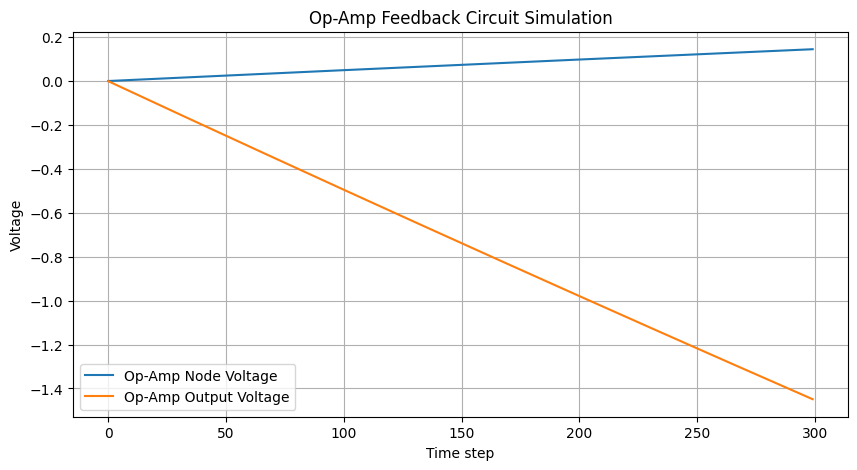

In [37]:
# Constant voltage source
V_in = 5.0

# Create node for op-amp input
OpAmpNode = Node("OpAmpNode", initial_V=0)

# Create resistor from input voltage source to node (1000 ohm)
R1 = Resistor(R=1000, V1=lambda: V_in, V2=lambda: OpAmpNode.V)

# Create resistor from op-amp output back to node (10,000 ohm)
# For simplicity, model op-amp output voltage as a variable
OpAmpOutput = [0.0]  # mutable container to hold output voltage

R2 = Resistor(R=10000, V1=lambda: OpAmpOutput[0], V2=lambda: OpAmpNode.V)

# Add flows to node
OpAmpNode.add_flow(lambda: R1.flow())
OpAmpNode.add_flow(lambda: R2.flow())

# Create capacitor to store charge at node
CapOpAmp = Capacitor(C=1.0, node=OpAmpNode)

# Simulation parameters

dt = 0.1
steps = 300

# History for plotting
OpAmpNode_history = []
OpAmpOutput_history = []

for _ in range(steps):
    # Simple op-amp model: output voltage tries to drive node voltage to zero
    # Here, output voltage is proportional to negative node voltage (ideal op-amp)
    OpAmpOutput[0] = -10 * OpAmpNode.V  # gain of 10

    # Update capacitor voltage at node
    CapOpAmp.update(dt)

    # Record history
    OpAmpNode_history.append(OpAmpNode.V)
    OpAmpOutput_history.append(OpAmpOutput[0])

# ============================================================
# PLOT RESULTS
# ============================================================

plt.figure(figsize=(10,5))
plt.plot(OpAmpNode_history, label="Op-Amp Node Voltage")
plt.plot(OpAmpOutput_history, label="Op-Amp Output Voltage")
plt.xlabel("Time step")
plt.ylabel("Voltage")
plt.title("Op-Amp Feedback Circuit Simulation")
plt.legend()
plt.grid(True)
plt.show()


# NegGainOpAmp

## Definition Script

In [38]:
class NegGainOpAmp:
    def __init__(self, name, Rin, Rf, gain=-10000):
        """
        name : label for the block
        Rin  : input resistor
        Rf   : feedback resistor
        gain : large negative gain to enforce virtual ground
        """
        self.name = name
        self.Rin = Rin
        self.Rf = Rf
        self.gain = gain

    def compute(self, Vin):
        """
        Vin : input voltage
        Returns a dictionary with input and output.
        """
        # Effective closed-loop gain (classic inverting amplifier)
        closed_loop_gain = -(self.Rf / self.Rin)

        # Output voltage using closed-loop gain
        Vout = closed_loop_gain * Vin

        return {
            "stage": self.name,
            "input": Vin,
            "output": Vout,
            "Rin": self.Rin,
            "Rf": self.Rf,
            "closed_loop_gain": closed_loop_gain
        }


## Implement

In [39]:
stage1 = NegGainOpAmp("Stage1", Rin=10_000, Rf=20_000)
stage2 = NegGainOpAmp("Stage2", Rin=5_000,  Rf=15_000)

# First stage
result1 = stage1.compute(Vin=1.0)

# Second stage uses output of first stage
result2 = stage2.compute(Vin=result1["output"])

result1, result2


({'stage': 'Stage1',
  'input': 1.0,
  'output': -2.0,
  'Rin': 10000,
  'Rf': 20000,
  'closed_loop_gain': -2.0},
 {'stage': 'Stage2',
  'input': -2.0,
  'output': 6.0,
  'Rin': 5000,
  'Rf': 15000,
  'closed_loop_gain': -3.0})

## Example: chaining multiple op‑amp stages

In [45]:
stage1 = NegGainOpAmp("Stage1", Rin=10_000, Rf=20_000)
stage2 = NegGainOpAmp("Stage2", Rin=5_000,  Rf=15_000)

# First stage
result1 = stage1.compute(Vin=1.0)

# Second stage uses output of first stage
result2 = stage2.compute(Vin=result1["output"])

result1, result2


({'stage': 'Stage1',
  'input': 1.0,
  'output': -2.0,
  'Rin': 10000,
  'Rf': 20000,
  'closed_loop_gain': -2.0},
 {'stage': 'Stage2',
  'input': -2.0,
  'output': 6.0,
  'Rin': 5000,
  'Rf': 15000,
  'closed_loop_gain': -3.0})

# Derive two‑stage neg‑gain amplifier cascade
1. with an 8‑sample sine wave input
2. and Stage‑2 output In a dictionary

## First: your neg‑gain op‑amp class (from earlier)

In [5]:
class NegGainOpAmp:
    def __init__(self, name, Rin, Rf, gain=-10000):
        self.name = name
        self.Rin = Rin
        self.Rf = Rf
        self.gain = gain

    def compute(self, Vin):
        closed_loop_gain = -(self.Rf / self.Rin)
        Vout = closed_loop_gain * Vin
        return {
            "stage": self.name,
            "input": Vin,
            "output": Vout,
            "closed_loop_gain": closed_loop_gain
        }


## Second: generate the input: an 8‑sample sine wave

In [6]:
import numpy as np

# 8-sample sine wave
samples = 8
input_signal = {i: np.sin(2 * np.pi * i / samples) for i in range(samples)}


In [65]:
# verify input_signal

## Third: build your two‑stage cascade

### notes:
Stage‑1 gain = –2
Stage‑2 gain = –3
Total cascade gain = +6

In [21]:
stage1 = NegGainOpAmp("Stage1", Rin=10_000, Rf=20_000)         # creating 3 blocks or instances
stage2 = NegGainOpAmp("Stage2", Rin=5_000,  Rf=15_000)
stage3 = NegGainOpAmp("Stage3", Rin=5_000,  Rf=10_000)

In [22]:
# verify 
stage1.__dict__

{'name': 'Stage1', 'Rin': 10000, 'Rf': 20000, 'gain': -10000}

In [23]:
# verify 
stage1.compute

<bound method NegGainOpAmp.compute of <__main__.NegGainOpAmp object at 0x738f1c12b6a0>>

In [24]:
# verify 
stage3

## Fourth: drive the cascade and log Stage‑2 output
We create a dictionary that logs:

"input" — the sine wave

"stage2_output" — the final cascade output

In [33]:
log = {
    "input": {},
    "stage2_output": {},
    "stage3_output": {}
}

for i, Vin in input_signal.items():               # samples of sin e
    # Stage 1
    r1 = stage1.compute(Vin)                      # This is the return of stage1.compute = dict of the returns of stage1.compute
    #                                               "stage": self.name,"input": Vin, "output": Vout, "closed_loop_gain": closed_loop_gain
    # Stage 2
    r2 = stage2.compute(r1["output"])
    # Stage 3
    r3 = stage3.compute(r2["output"])
    # Log input and final output                 #this a dictionary of 2 keys ....  "input": {}, "stage2_output": {}
    log["input"][i] = Vin
    log["stage3_output"][i] = r3["output"]


## Fifth: inspect the results

In [36]:
# verify log ["input"]

In [31]:
# verify log ["stage33_output"]

In [37]:
# verify log ["stage3_output"]

To show the 5th row (meaning the sample with index 5) of your stage2_output dictionary, you simply index it by key:

python
log["stage2_output"][5]
That’s it — dictionaries in Python are keyed collections, so you access an entry by its key, not by row number.

In [39]:
# verify log["stage3_output"][5]

In [63]:
# verify log["input"][5]

### This is exactly what your cascade should produce:

#### notes 
Stage‑1 multiplies by –2

Stage‑2 multiplies by –3

Total gain = +6

So the output is a scaled sine wave with amplitude 6.

# next